## Figure S7

### Observed Hi-C matrices, observed/expected matrices, and insulation scores for the four observed topologically observed domains on the P. pacificus hermaphrodite X chromosome.

Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

import cooler
import bioframe

import cooltools
import cooltools.expected
from cooltools import snipping

import cooltools.lib.plotting
import multiprocess

from matplotlib.colors import LogNorm
from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')
from scipy import interpolate
from mpl_toolkits.axes_grid import make_axes_locatable
import pyBigWig
import csv

from cooltools.lib.numutils import adaptive_coarsegrain, interp_nan
from cooltools.insulation import calculate_insulation_score, find_boundaries
import pyBigWig
from scipy import linalg
from scipy.signal import argrelextrema


cooltools.__version__

/state/partition1/job-2110119/ipykernel_1421815/2824918811.py:20: MatplotlibDeprecationWarning: 
The mpl_toolkits.axes_grid module was deprecated in Matplotlib 2.1 and will be removed two minor releases later. Use mpl_toolkits.axes_grid1 and mpl_toolkits.axisartist, which provide the same functionality instead.
  from mpl_toolkits.axes_grid import make_axes_locatable


'0.4.0'

Define functions to smooth matrix, calculate expected values, and format ticks

In [2]:
def cgi_region(clr,region):
    cg = adaptive_coarsegrain(clr.matrix(balance=True).fetch(region),
                              clr.matrix(balance=False).fetch(region),
                              cutoff=3, max_levels=8)
    cgi = interp_nan(cg)
    return(cg)

nthreads=4

def my_expected(clr,regions):
    with multiprocess.Pool(nthreads) as pool:
        expected = cooltools.expected.diagsum(
            clr,
            regions=regions,
            transforms={
                'balanced': lambda p: p['count'] * p['weight1'] * p['weight2']
            },
            map=pool.map
        )
    expected['balanced.avg'] = expected['balanced.sum'] / expected['n_valid']
    return(expected)
    
def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

Load chromosome sizes file

In [3]:
ps312=bioframe.read_table('/home/aa7013/hic-to-cool/chrom-sizes_files/pristionchus_pacificus.PRJNA12644.WBPS16.genomic.RS.chrom.sizes',schema='bed3')
ps312=bioframe.parse_regions(ps312)

In [4]:
print(ps312)

  chrom  start       end            name
0     I      0  39556110    I:0-39556110
1    IV      0  30938908   IV:0-30938908
2     V      0  23911096    V:0-23911096
3    II      0  23310661   II:0-23310661
4   III      0  21666382  III:0-21666382
5     X      0  17126273    X:0-17126273


Load cool files

In [5]:
bin = str(5000) # resolution

ppaclr = cooler.Cooler("/home/aa7013/hic-to-cool/PS312_JK88_JK122_PRJNA12644-WBPS16-RS/PS312_JK88_JK122_PRJNA12644-WBPS16-RS_30_5000_raw.cool")

Calculate insulation score

In [6]:
windows = [20000] # resolution of your cool file is step size, this is bin size

ppains = calculate_insulation_score(ppaclr, windows, verbose=True)

INFO:root:Processing I
INFO:root:Processing IV
INFO:root:Processing V
INFO:root:Processing II
INFO:root:Processing III
INFO:root:Processing X


Calculate expected values. This function calculates the expected values as a dataframe. When plotting, you will convert it to a plottable matrix with linalg.toeplitz

In [7]:
expected_X = my_expected(ppaclr, ps312.iloc[[5]].reset_index())

In [8]:
print(expected_X)

            region  diag  n_valid  count.sum  balanced.sum  balanced.avg
0     X:0-17126273     0     2896        NaN           NaN           NaN
1     X:0-17126273     1     2764        NaN           NaN           NaN
2     X:0-17126273     2     2714   679359.0     71.049718      0.026179
3     X:0-17126273     3     2681   452971.0     47.317249      0.017649
4     X:0-17126273     4     2659   345484.0     36.081616      0.013570
...            ...   ...      ...        ...           ...           ...
3421  X:0-17126273  3421        0        0.0      0.000000           NaN
3422  X:0-17126273  3422        0        0.0      0.000000           NaN
3423  X:0-17126273  3423        0        0.0      0.000000           NaN
3424  X:0-17126273  3424        0        0.0      0.000000           NaN
3425  X:0-17126273  3425        0        0.0      0.000000           NaN

[3426 rows x 6 columns]


Plot observed matrix, observed/expected matrix, and insulation for each TAD

Note: I didn't align the colorbars properly. Instead, I manually moved them into place in Illustrator.

/ext3/miniconda3/lib/python3.9/site-packages/cooltools/lib/numutils.py:1355: RuntimeWarning: invalid value encountered in true_divide
  val_cur = ar_cur / armask_cur
/ext3/miniconda3/lib/python3.9/site-packages/cooltools/lib/numutils.py:1355: RuntimeWarning: invalid value encountered in true_divide
  val_cur = ar_cur / armask_cur
/ext3/miniconda3/lib/python3.9/site-packages/cooltools/lib/numutils.py:1355: RuntimeWarning: invalid value encountered in true_divide
  val_cur = ar_cur / armask_cur
/ext3/miniconda3/lib/python3.9/site-packages/cooltools/lib/numutils.py:1355: RuntimeWarning: invalid value encountered in true_divide
  val_cur = ar_cur / armask_cur


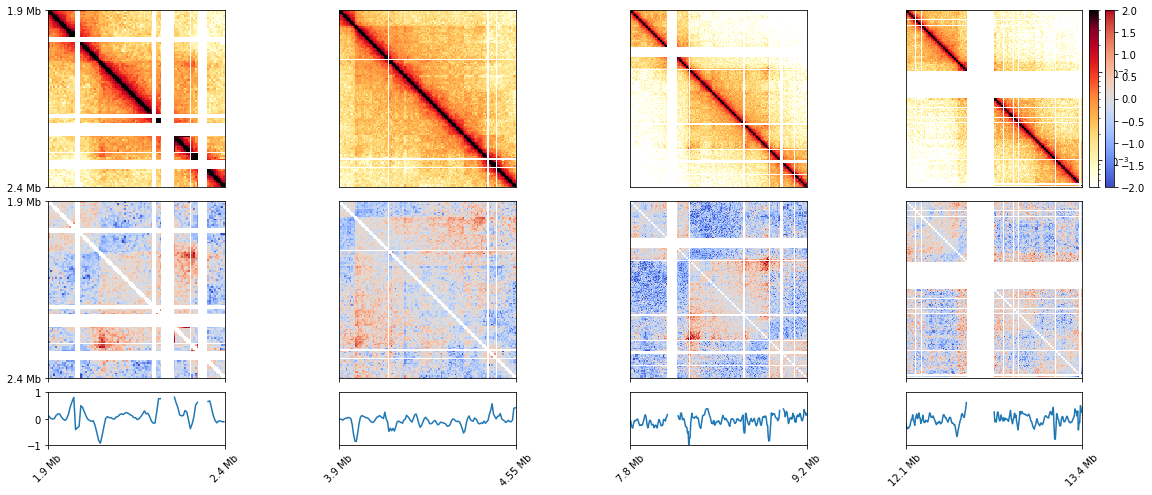

In [8]:
f, axs = plt.subplots(
    figsize=(20, 8),
    ncols=4,
    nrows=1
)

norms = LogNorm(vmin=0.0005,vmax=0.05)
obsexp = [-2,2]
ins_min, ins_max = [-1.0,1.0]

ax = axs[0]

region = 'X:1,900,000-2,400,000'
start, end = 1_900_000, 2_400_000
extents = (start, end, end, start)

clr_region = cgi_region(ppaclr,region)

# Matrix
im = ax.matshow(
    clr_region,
    cmap='fall',
    norm=norms,
    extent=extents
)
divider = make_axes_locatable(ax)
format_ticks(ax,rotate=False)
ax.tick_params(axis="x", bottom=False, top=False, labelbottom=False, labeltop=False)
ax.set_yticks([start, end])

# O/E
ax_oe = divider.append_axes("bottom", size='100%', pad=0.2, sharex=ax)
obs_exp = clr_region/linalg.toeplitz(expected_X['balanced.avg'][0:len(clr_region)])   
im_oe = ax_oe.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0],vmax=obsexp[1],
    extent=extents
)
format_ticks(ax_oe,rotate=False)
ax_oe.tick_params(axis="x", bottom=True, top=False, labelbottom=False, labeltop=False, pad = 10)
ax_oe.set_xticks([start, end])
ax_oe.set_yticks([start, end])

# Insulation
ax_ins = divider.append_axes("bottom", size="30%", pad=0.2, sharex=ax) # axis for insulation score
ins_region = bioframe.select(ppains, region)
ax_ins.plot(ins_region[['start', 'end']].mean(axis=1), 
            ins_region['log2_insulation_score_20000']) # where you input the window size you used

# force min/max values
ax_ins.set_ylim([ins_min,ins_max])

plt.xticks(rotation=45)

ax = axs[1]

region = 'X:3,900,000-4,550,000'
start, end = 3_900_000, 4_550_000
extents = (start, end, end, start)

clr_region = cgi_region(ppaclr,region)
# Matrix
im = ax.matshow(
    clr_region,
    cmap='fall',
    norm=norms,
    extent=extents
)
divider = make_axes_locatable(ax)
format_ticks(ax,rotate=False)
ax.tick_params(axis="x", bottom=False, top=False, labelbottom=False, labeltop=False)
ax.set_yticks([])

# O/E
ax_oe = divider.append_axes("bottom", size='100%', pad=0.2, sharex=ax)
obs_exp = clr_region/linalg.toeplitz(expected_X['balanced.avg'][0:len(clr_region)])   
im_oe = ax_oe.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0],vmax=obsexp[1],
    extent=extents
)
format_ticks(ax_oe,rotate=False)
ax_oe.tick_params(axis="x", bottom=True, top=False, labelbottom=False, labeltop=False, pad = 10)
ax_oe.set_xticks([start, end])
ax_oe.set_yticks([])

# Insulation
ax_ins = divider.append_axes("bottom", size="30%", pad=0.2, sharex=ax) # axis for insulation score
ins_region = bioframe.select(ppains, region)
ax_ins.plot(ins_region[['start', 'end']].mean(axis=1), 
            ins_region['log2_insulation_score_20000']) # where you input the window size you used
ax_ins.set_yticks([])

# force min/max values
ax_ins.set_ylim([ins_min,ins_max])

plt.xticks(rotation=45)

ax = axs[2]

region = 'X:7,800,000-9,200,000'
start, end = 7_800_000, 9_200_000
extents = (start, end, end, start)

clr_region = cgi_region(ppaclr,region)

# Matrix
im = ax.matshow(
    clr_region,
    cmap='fall',
    norm=norms,
    extent=extents
)
divider = make_axes_locatable(ax)
format_ticks(ax,rotate=False)
ax.tick_params(axis="x", bottom=False, top=False, labelbottom=False, labeltop=False)
ax.set_yticks([])

# O/E
ax_oe = divider.append_axes("bottom", size='100%', pad=0.2, sharex=ax)
obs_exp = clr_region/linalg.toeplitz(expected_X['balanced.avg'][0:len(clr_region)])   
im_oe = ax_oe.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0],vmax=obsexp[1],
    extent=extents
)
format_ticks(ax_oe,rotate=False)
ax_oe.tick_params(axis="x", bottom=True, top=False, labelbottom=False, labeltop=False, pad = 10)
ax_oe.set_xticks([start, end])
ax_oe.set_yticks([])

# Insulation
ax_ins = divider.append_axes("bottom", size="30%", pad=0.2, sharex=ax) # axis for insulation score
ins_region = bioframe.select(ppains, region)
ax_ins.plot(ins_region[['start', 'end']].mean(axis=1), 
            ins_region['log2_insulation_score_20000']) # where you input the window size you used
ax_ins.set_yticks([])

# force min/max values
ax_ins.set_ylim([ins_min,ins_max])

plt.xticks(rotation=45)

ax = axs[3]

region = 'X:12,100,000-13,400,000'
start, end = 12_100_000, 13_400_000
extents = (start, end, end, start)

clr_region = cgi_region(ppaclr,region)
# Matrix
im = ax.matshow(
    clr_region,
    cmap='fall',
    norm=norms,
    extent=extents
)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax)
format_ticks(ax,rotate=False)
ax.tick_params(axis="x", bottom=False, top=False, labelbottom=False, labeltop=False)
ax.set_yticks([])

# O/E
ax_oe = divider.append_axes("bottom", size='100%', pad=0.2, sharex=ax)
obs_exp = clr_region/linalg.toeplitz(expected_X['balanced.avg'][0:len(clr_region)])   
im_oe = ax_oe.matshow(
    np.log2(obs_exp),
    cmap='coolwarm',
    vmin=obsexp[0],vmax=obsexp[1],
    extent=extents
)
cax_oe = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_oe, cax=cax_oe)
format_ticks(ax_oe,rotate=False)
ax_oe.tick_params(axis="x", bottom=True, top=False, labelbottom=False, labeltop=False, pad = 10)
ax_oe.set_xticks([start, end])
ax_oe.set_yticks([])

# Insulation
ax_ins = divider.append_axes("bottom", size="30%", pad=0.2, sharex=ax) # axis for insulation score
ins_region = bioframe.select(ppains, region)
ax_ins.plot(ins_region[['start', 'end']].mean(axis=1), 
            ins_region['log2_insulation_score_20000']) # where you input the window size you used
ax_ins.set_yticks([])

# force min/max values
ax_ins.set_ylim([ins_min,ins_max])

plt.xticks(rotation=45)

# save
plt.savefig("chrX_zoom_PS312_TADs_5kb_20kb_h.pdf", format='pdf', dpi=300)